In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from collections import Counter
######----------For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(15,5)})
plt.style.use('fivethirtyeight')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving open_orginal.csv to open_orginal.csv


In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('open_orginal.csv')

In [ ]:
data

,internet,water_access,region,age,education,electricity,marital,media,residence,sex_HH,Family_size,water_treat,under5,wealth,open
0,0,0,10,2,1,1,1,1,1,2,1,0,0,3,0
1,1,1,10,2,3,1,1,1,1,1,2,0,0,3,0
2,0,1,10,4,0,0,2,0,1,1,1,1,0,2,0
3,0,0,10,2,0,1,1,0,1,2,1,0,0,3,0
4,0,0,10,1,2,1,0,0,1,2,1,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12803,0,1,10,4,0,0,3,0,2,2,1,0,0,1,1
12804,0,1,10,2,2,0,3,0,2,1,1,0,0,1,1
12805,0,1,10,1,2,0,0,0,2,1,2,0,1,1,1
12806,0,1,10,2,2,0,1,0,2,2,2,0,0,1,1


In [ ]:
import pandas as pd

# Sample DataFrame (replace with your own)

# Display unique values for each column

for col in data.columns:
    print(f"\nColumn: {col}")
    counts = data[col].value_counts(dropna=False)
    percentages = data[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary)





Column: internet
          Count  Percentage (%)
internet                       
0          9283           72.48
1          3525           27.52

Column: water_access
              Count  Percentage (%)
water_access                       
1              9876           77.11
0              2932           22.89

Column: region
        Count  Percentage (%)
region                       
5        1544           12.05
3        1454           11.35
1        1442           11.26
9        1440           11.24
2        1433           11.19
7        1228            9.59
4        1172            9.15
10       1068            8.34
8        1024            8.00
6        1003            7.83

Column: age
     Count  Percentage (%)
age                       
2     4901           38.27
3     3148           24.58
1     2684           20.96
4     2075           16.20

Column: education
           Count  Percentage (%)
education                       
1           5474           42.74
2           4812   

In [ ]:
print(data.columns) # to show the columns of IV variables

Index(['internet', 'water_access', 'region', 'age', 'education', 'electricity',
       'marital', 'media', 'residence', 'sex_HH', 'Family_size', 'water_treat',
       'under5', 'wealth', 'open'],
      dtype='object')


In [ ]:
data.nunique()

,0
internet,2
water_access,2
region,10
age,4
education,4
electricity,2
marital,4
media,2
residence,2
sex_HH,2


In [ ]:
# Check for missing values in each column
print(data.isnull().sum())

internet        0
water_access    0
region          0
age             0
education       0
electricity     0
marital         0
media           0
residence       0
sex_HH          0
Family_size     0
water_treat     0
under5          0
wealth          0
open            0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# Step 1: Identify non-numeric columns
non_numeric_cols = data.select_dtypes(include=['object', 'string']).columns

# Step 2: Flag problematic entries (optional but useful for review)
problematic = data[non_numeric_cols].applymap(lambda x: not pd.to_numeric(x, errors='coerce') if isinstance(x, str) else False)

# Step 3: Encode non-numeric columns (if you want to impute them)
# Option A: Drop them if irrelevant
# df_numeric = df.drop(columns=non_numeric_cols)

# Option B: Encode them (Label Encoding or One-Hot)
df_encoded = data.copy()
for col in non_numeric_cols:
    df_encoded[col] = pd.factorize(data[col])[0].astype(float)  # NaNs preserved

# Step 4: Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
df_imputed_array = imputer.fit_transform(df_encoded)

# Step 5: Restore DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=data.columns)

/tmp/ipykernel_4302/3182186466.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  problematic = data[non_numeric_cols].applymap(lambda x: not pd.to_numeric(x, errors='coerce') if isinstance(x, str) else False)


In [ ]:
# Check for missing values in each column
print(df_imputed.isnull().sum())

internet        0
water_access    0
region          0
age             0
education       0
electricity     0
marital         0
media           0
residence       0
sex_HH          0
Family_size     0
water_treat     0
under5          0
wealth          0
open            0
dtype: int64


In [ ]:
# Step 6: Display a preview
print("🔍 Imputed Data Preview:")
print(df_imputed.head())

# Step 7: Save to CSV (preserving original structure)
df_imputed.to_csv('imputed_outputt.csv', index=False)
print("✅ Imputed data saved as 'imputed_outputt.csv'")

🔍 Imputed Data Preview:
   internet  water_access  region  age  education  electricity  marital  \
0       0.0           0.0    10.0  2.0        1.0          1.0      1.0   
1       1.0           1.0    10.0  2.0        3.0          1.0      1.0   
2       0.0           1.0    10.0  4.0        0.0          0.0      2.0   
3       0.0           0.0    10.0  2.0        0.0          1.0      1.0   
4       0.0           0.0    10.0  1.0        2.0          1.0      0.0   

   media  residence  sex_HH  Family_size  water_treat  under5  wealth  open  
0    1.0        1.0     2.0          1.0          0.0     0.0     3.0   0.0  
1    1.0        1.0     1.0          2.0          0.0     0.0     3.0   0.0  
2    0.0        1.0     1.0          1.0          1.0     0.0     2.0   0.0  
3    0.0        1.0     2.0          1.0          0.0     0.0     3.0   0.0  
4    0.0        1.0     2.0          1.0          0.0     0.0     3.0   0.0  
✅ Imputed data saved as 'imputed_outputt.csv'


In [ ]:
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 6: Display a preview
print("🔍 Imputed Data Preview:")
print(df_imputed.head())

# Step 7: Save to CSV (preserving original structure) into Google Drive
output_path = '/content/drive/MyDrive/imputed_outputt.csv'
df_imputed.to_csv(output_path, index=False)

print(f"✅ Imputed data saved as '{output_path}'")


Mounted at /content/drive
🔍 Imputed Data Preview:
   internet  water_access  region  age  education  electricity  marital  \
0       0.0           0.0    10.0  2.0        1.0          1.0      1.0   
1       1.0           1.0    10.0  2.0        3.0          1.0      1.0   
2       0.0           1.0    10.0  4.0        0.0          0.0      2.0   
3       0.0           0.0    10.0  2.0        0.0          1.0      1.0   
4       0.0           0.0    10.0  1.0        2.0          1.0      0.0   

   media  residence  sex_HH  Family_size  water_treat  under5  wealth  open  
0    1.0        1.0     2.0          1.0          0.0     0.0     3.0   0.0  
1    1.0        1.0     1.0          2.0          0.0     0.0     3.0   0.0  
2    0.0        1.0     1.0          1.0          1.0     0.0     2.0   0.0  
3    0.0        1.0     2.0          1.0          0.0     0.0     3.0   0.0  
4    0.0        1.0     2.0          1.0          0.0     0.0     3.0   0.0  
✅ Imputed data saved as '/conte

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving open_orginal.csv to open_orginal (1).csv


In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('open_orginal.csv')

In [ ]:
import pandas as pd




# List of categorical columns to encode
categorical_cols = [
    'internet', 'water_access', 'region', 'age', 'education', 'electricity',
       'marital', 'media', 'residence', 'sex_HH', 'Family_size', 'water_treat',
       'under5', 'wealth', 'open'
]

# Apply one-hot encoding with dtype=int to force 0/1
df = pd.get_dummies(data, columns=categorical_cols, drop_first=False, dtype=int)

print(df.head())





   internet_0  internet_1  water_access_0  water_access_1  region_1  region_2  \
0           1           0               1               0         0         0   
1           0           1               0               1         0         0   
2           1           0               0               1         0         0   
3           1           0               1               0         0         0   
4           1           0               1               0         0         0   

   region_3  region_4  region_5  region_6  ...  water_treat_1  under5_0  \
0         0         0         0         0  ...              0         1   
1         0         0         0         0  ...              0         1   
2         0         0         0         0  ...              1         1   
3         0         0         0         0  ...              0         1   
4         0         0         0         0  ...              0         1   

   under5_1  under5_2  under5_3  wealth_1  wealth_2  wealth_3 

In [ ]:
import pandas as pd



# List of original categorical variables
original_vars = [
'internet', 'water_access', 'region', 'age', 'education', 'electricity',
       'marital', 'media', 'residence', 'sex_HH', 'Family_size', 'water_treat',
       'under5', 'wealth', 'open'
]

# Identify and drop the first dummy column for each variable
for var in original_vars:
    # Find all dummy columns that start with the variable name + underscore
    dummy_cols = [col for col in df.columns if col.startswith(var.strip() + '_')]

    # Sort to ensure consistent order, then drop the first one
    if dummy_cols:
        dummy_cols.sort()
        df.drop(columns=dummy_cols[0], inplace=True)

# Display the cleaned DataFrame
print(df.head())


   internet_1  water_access_1  region_2  region_3  region_4  region_5  \
0           0               0         0         0         0         0   
1           1               1         0         0         0         0   
2           0               1         0         0         0         0   
3           0               0         0         0         0         0   
4           0               0         0         0         0         0   

   region_6  region_7  region_8  region_9  ...  sex_HH_2  Family_size_2  \
0         0         0         0         0  ...         1              0   
1         0         0         0         0  ...         0              1   
2         0         0         0         0  ...         0              0   
3         0         0         0         0  ...         1              0   
4         0         0         0         0  ...         1              0   

   Family_size_3  water_treat_1  under5_1  under5_2  under5_3  wealth_2  \
0              0              0    

In [ ]:
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

# Save to a folder in your Drive
df.to_csv('/content/drive/MyDrive/df.csv', index=False)

Mounted at /content/drive


In [1]:
from google.colab import files
uploaded = files.upload()

Saving defecations.csv to defecations.csv


In [4]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('defecations.csv')

In [ ]:
data

,internet_1,water_access_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,...,sex_HH_2,Family_size_2,Family_size_3,water_treat_1,under5_1,under5_2,under5_3,wealth_2,wealth_3,open
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12803,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
12804,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12805,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
12806,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1


In [ ]:
# Check for missing values in each column
print(data.isnull().sum())

internet_1        0
water_access_1    0
region_2          0
region_3          0
region_4          0
region_5          0
region_6          0
region_7          0
region_8          0
region_9          0
region_10         0
age_2             0
age_3             0
age_4             0
education_1       0
education_2       0
education_3       0
electricity_1     0
marital_1         0
marital_2         0
marital_3         0
media_1           0
residence_2       0
sex_HH_2          0
Family_size_2     0
Family_size_3     0
water_treat_1     0
under5_1          0
under5_2          0
under5_3          0
wealth_2          0
wealth_3          0
open              0
dtype: int64


In [ ]:
X = data.drop('open', axis=1)
y = data['open']



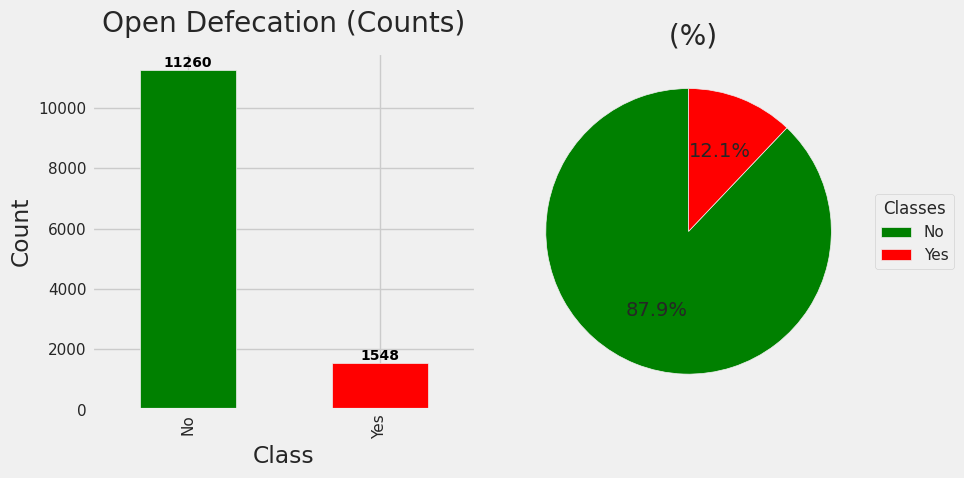

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load the dataset

target_column = 'open'
y = data[target_column]

# Replace 0 with "No" and 1 with "Yes" for better representation
y_mapped = y.map({0: 'No', 1: 'Yes'})

# Count occurrences of each class in the dataset
class_counts = Counter(y_mapped)
class_counts_series = pd.Series(class_counts)

# Colors for "No" and "Yes"
bar_colors = ['green', 'red']
pie_colors = ['green', 'red']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Bar Chart ---
axes[0].set_title('Open Defecation (Counts)', pad=15)
class_counts_series.plot(kind='bar', color=bar_colors, ax=axes[0])

# Add count numbers on top of the bars
for i, count in enumerate(class_counts_series):
    axes[0].text(i, count + 0.5, f"{count}", ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='black')

axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# --- Pie Chart ---
sizes = [class_counts['No'], class_counts['Yes']]
wedges, texts, autotexts = axes[1].pie(
    sizes, autopct='%1.1f%%', startangle=90, colors=pie_colors
)

axes[1].legend(wedges, ['No', 'Yes'], title='Classes',
               loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].set_title(' (%)')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X = data.drop('open', axis=1)
y = data['open']


# Step 2: Split Datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
def calculate_metrics(y_true, y_preds, y_probs):
    accuracy = accuracy_score(y_true, y_preds)
    auc_score = roc_auc_score(y_true, y_probs)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    return accuracy, auc_score, precision, recall, f1

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

# 10-fold CV
rf_acc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
rf_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print("Random Forest Mean CV Accuracy:", rf_acc.mean())
print("Random Forest Mean CV ROC-AUC:", rf_auc.mean())

# Final fit and predictions
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)


Random Forest Mean CV Accuracy: 0.8785865091463414
Random Forest Mean CV ROC-AUC: 0.8104664636693268


In [ ]:
# LightGBM
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lgb_model = LGBMClassifier(random_state=42)

# 10-fold CV
lgb_acc = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='accuracy')
lgb_auc = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("LightGBM Mean CV Accuracy:", lgb_acc.mean())
print("LightGBM Mean CV ROC-AUC:", lgb_auc.mean())

# Final fit and predictions
lgb_model.fit(X_train, y_train)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred = lgb_model.predict(X_test)


[LightGBM] [Info] Number of positive: 1114, number of negative: 8107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 9221, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120811 -> initscore=-1.984771
[LightGBM] [Info] Start training from score -1.984771
[LightGBM] [Info] Number of positive: 1114, number of negative: 8107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001808 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 9221, number of used features: 32
[LightGBM] [Info] [binary:Bo

In [ ]:
!pip install catboost



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
# CatBoost
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cat_model = CatBoostClassifier(verbose=0, random_state=42)

cat_acc = cross_val_score(cat_model, X_train, y_train, cv=cv, scoring='accuracy')
cat_auc = cross_val_score(cat_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("CatBoost Mean CV Accuracy:", cat_acc.mean())
print("CatBoost Mean CV ROC-AUC:", cat_auc.mean())

cat_model.fit(X_train, y_train)
cat_prob = cat_model.predict_proba(X_test)[:, 1]
cat_pred = cat_model.predict(X_test)


CatBoost Mean CV Accuracy: 0.8875655487804878
CatBoost Mean CV ROC-AUC: 0.846171450001305


In [ ]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ada_model = AdaBoostClassifier(random_state=42)

ada_acc = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring='accuracy')
ada_auc = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("AdaBoost Mean CV Accuracy:", ada_acc.mean())
print("AdaBoost Mean CV ROC-AUC:", ada_auc.mean())

ada_model.fit(X_train, y_train)
ada_prob = ada_model.predict_proba(X_test)[:, 1]
ada_pred = ada_model.predict(X_test)


AdaBoost Mean CV Accuracy: 0.8882493330792682
AdaBoost Mean CV ROC-AUC: 0.8586289638548885


In [ ]:
# XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_acc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
xgb_auc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("XGBoost Mean CV Accuracy:", xgb_acc.mean())
print("XGBoost Mean CV ROC-AUC:", xgb_auc.mean())

xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Mean CV Accuracy: 0.8828813833841463
XGBoost Mean CV ROC-AUC: 0.8366268798987712


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

dt_acc = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='accuracy')
dt_auc = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("Decision Tree Mean CV Accuracy:", dt_acc.mean())
print("Decision Tree Mean CV ROC-AUC:", dt_auc.mean())

dt_model.fit(X_train, y_train)
dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_pred = dt_model.predict(X_test)


Decision Tree Mean CV Accuracy: 0.8474500762195122
Decision Tree Mean CV ROC-AUC: 0.6868850080395563


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

# 10-fold CV
lr_acc = cross_val_score(lr, X_train, y_train, cv=cv, scoring='accuracy')
lr_auc = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')
print("Logistic Regression Mean CV Accuracy:", lr_acc.mean())
print("Logistic Regression Mean CV ROC-AUC:", lr_auc.mean())

# Final fit and predictions
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = lr.predict(X_test)


Logistic Regression Mean CV Accuracy: 0.8908835746951219
Logistic Regression Mean CV ROC-AUC: 0.8633611145676546


In [ ]:
# Dummy Classifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dummy = DummyClassifier(strategy="uniform", random_state=42)

# 10-fold CV
dummy_acc = cross_val_score(dummy, X_train, y_train, cv=cv, scoring='accuracy')
dummy_auc = cross_val_score(dummy, X_train, y_train, cv=cv, scoring='roc_auc')
print("Dummy Mean CV Accuracy:", dummy_acc.mean())
print("Dummy Mean CV ROC-AUC:", dummy_auc.mean())

# Final fit and predictions
dummy.fit(X_train, y_train)
dummy_prob = dummy.predict_proba(X_test)[:, 1]
dummy_pred = dummy.predict(X_test)


Dummy Mean CV Accuracy: 0.4918999618902439
Dummy Mean CV ROC-AUC: 0.5


                 Model       AUC  Accuracy  Precision    Recall  F1 Score
0           LGBoosting  0.849750  0.891101   0.604027  0.290323  0.392157
1        Random Forest  0.804597  0.871585   0.453202  0.296774  0.358674
2        Decision Tree  0.668770  0.841920   0.332155  0.303226  0.317032
3              XGBoost  0.836510  0.886417   0.562092  0.277419  0.371490
4             AdaBoost  0.855470  0.895785   0.704762  0.238710  0.356627
5             CatBoost  0.846478  0.886027   0.561644  0.264516  0.359649
6  Logistic Regression  0.859190  0.892662   0.627737  0.277419  0.384787


/tmp/ipykernel_13152/3561568009.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray', label="Baseline (Random Guess)")


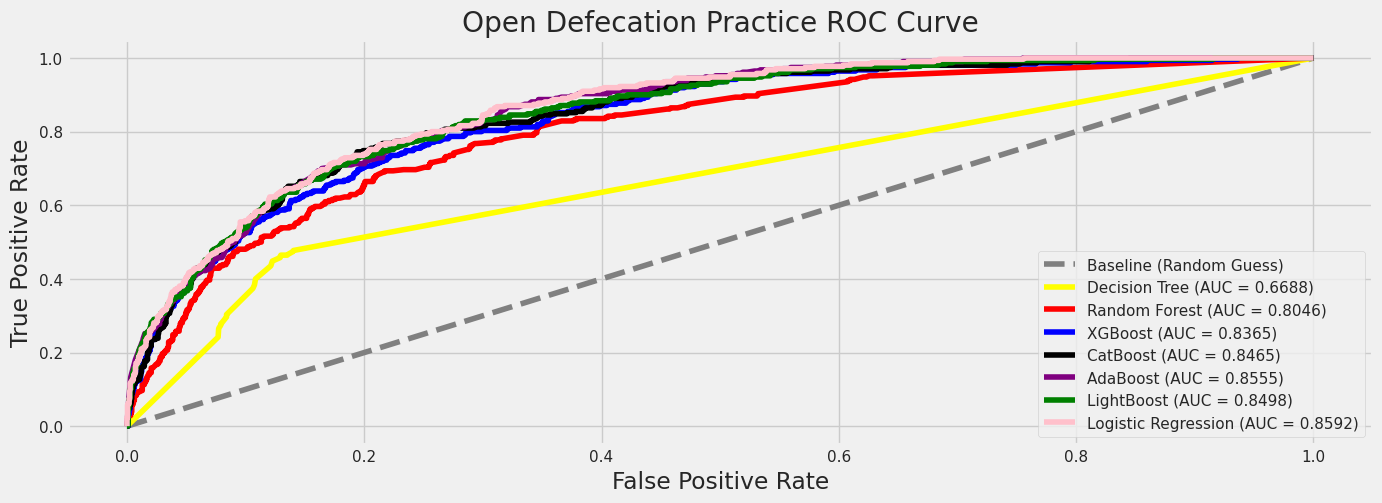

In [ ]:
# Required Libraries
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, roc_curve
)
import pandas as pd

# Consolidated Metrics
metrics = []
roc_curves = []

# Function to Evaluate Models and Compute Metrics
def evaluate_model(name, prob, pred):
    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_curves.append({'Model': name, 'FPR': fpr, 'TPR': tpr})

    # Metrics Calculation
    auc = roc_auc_score(y_test, prob)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    metrics.append({
      'Model': name,
      'AUC': auc,
      'Accuracy': accuracy,
      'Precision': precision,
      'Recall': recall,
      'F1 Score': f1
    })

# Evaluate Models
evaluate_model('LGBoosting', lgb_prob, lgb_pred)
evaluate_model('Random Forest', rf_prob, rf_pred)
evaluate_model('Decision Tree', dt_prob, dt_pred)
evaluate_model('XGBoost', xgb_prob, xgb_pred)
evaluate_model('AdaBoost', ada_prob, ada_pred)
evaluate_model('CatBoost', cat_prob, cat_pred)
evaluate_model('Logistic Regression', lr_prob, lr_pred)
# Display Consolidated Metrics
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Plot ROC Curve for Each Model

# Baseline (broken line for random classifier)
plt.plot([0, 1], [0, 1], 'k--', color='gray', label="Baseline (Random Guess)")

# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
plt.plot(dt_fpr, dt_tpr, color='yellow', label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.4f})")

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(rf_fpr, rf_tpr, color='red', label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})")

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(xgb_fpr, xgb_tpr, color='blue', label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.4f})")

# CatBoost
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)
plt.plot(cat_fpr, cat_tpr, color='black', label=f"CatBoost (AUC = {roc_auc_score(y_test, cat_prob):.4f})")

# AdaBoost
adaboost_fpr, adaboost_tpr, _ = roc_curve(y_test, ada_prob)
plt.plot(adaboost_fpr, adaboost_tpr, color='purple', label=f"AdaBoost (AUC = {roc_auc_score(y_test, ada_prob):.4f})")

# LightGBM
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_prob)
plt.plot(lgb_fpr, lgb_tpr, color='green', label=f"LightBoost (AUC = {roc_auc_score(y_test, lgb_prob):.4f})")
# Logistic regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(lr_fpr, lr_tpr, color='pink', label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.4f})")

# Plot Customization
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Open Defecation Practice ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier

In [ ]:
# Step 1: Prepare data


# Step 2: Split before balancing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Apply SMOTE only to training set
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)



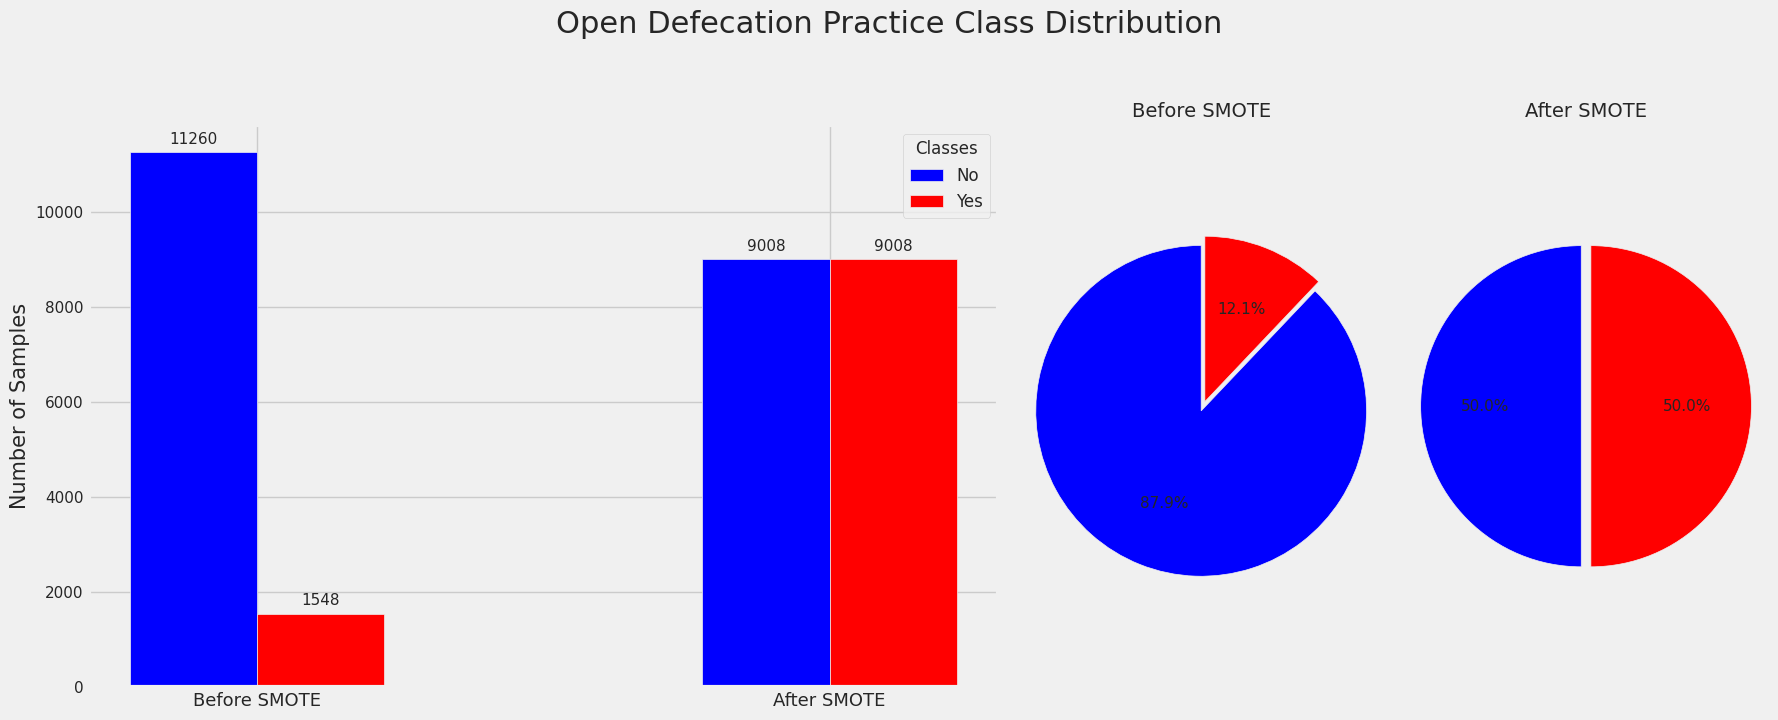

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.patches import Patch

# -----------------------------
# Class distribution
# -----------------------------
y = data['open']

before_counts = Counter(y)
after_counts = Counter(y_train_bal)

# -----------------------------
# Data for Bar Chart
# -----------------------------
labels_bar = ['Before SMOTE', 'After SMOTE']
no_values = [before_counts.get(0, 0), after_counts.get(0, 0)]
yes_values = [before_counts.get(1, 0), after_counts.get(1, 0)]

x = np.arange(len(labels_bar)) * 1.8
width = 0.4

# -----------------------------
# Data for Pie Charts
# -----------------------------
before_pie = [before_counts.get(0, 0), before_counts.get(1, 0)]
after_pie = [after_counts.get(0, 0), after_counts.get(1, 0)]

colors = ['blue', 'red']
explode = (0.03, 0.03)

# -----------------------------
# Create Figure (Bar chart wider)
# -----------------------------
fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[2.5, 1, 1])

# ===== BAR CHART =====
ax1 = fig.add_subplot(gs[0])

rects1 = ax1.bar(x - width/2, no_values, width, label='No', color='blue')
rects2 = ax1.bar(x + width/2, yes_values, width, label='Yes', color='red')

ax1.set_ylabel('Number of Samples', fontsize=15)

ax1.set_xticks(x)
ax1.set_xticklabels(labels_bar, fontsize=13)
ax1.legend(title='Classes', fontsize=12)

# Annotate bar values
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(
            f'{height}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=11
        )

# ===== PIE CHART: BEFORE SMOTE =====
ax2 = fig.add_subplot(gs[1])
ax2.pie(
    before_pie,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 11}
)
ax2.set_title('Before SMOTE', fontsize=14)
ax2.axis('equal')

# ===== PIE CHART: AFTER SMOTE =====
ax3 = fig.add_subplot(gs[2])
ax3.pie(
    after_pie,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 11}
)
ax3.set_title('After SMOTE', fontsize=14)
ax3.axis('equal')

# -----------------------------
# Legend BELOW the pie charts
# -----------------------------
legend_elements = [
    Patch(facecolor='blue', label='No'),
    Patch(facecolor='red', label='Yes')
]



# -----------------------------
# Main Title
# -----------------------------
fig.suptitle(
    'Open Defecation Practice Class Distribution',
    fontsize=22,
    y=1.03
)

plt.tight_layout()
plt.show()


In [ ]:


def calculate_metrics(y_true, y_preds, y_probs):
    accuracy = accuracy_score(y_true, y_preds)
    auc_score = roc_auc_score(y_true, y_probs)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    return accuracy, auc_score, precision, recall, f1

In [ ]:
# Logistic Regression (LR)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

# 10-fold CV on training set
lr_acc = cross_val_score(lr, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
lr_auc = cross_val_score(lr, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("Logistic Regression Mean CV Accuracy:", lr_acc.mean())
print("Logistic Regression Mean CV ROC-AUC:", lr_auc.mean())

# Final fit on balanced training set
lr.fit(X_train_bal, y_train_bal)

# Predictions on test set
lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

# Metrics (assuming you have a helper function)
lr_metrics = calculate_metrics(y_test, lr_preds, lr_probs)

# ROC curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)


Logistic Regression Mean CV Accuracy: 0.8616216419414297
Logistic Regression Mean CV ROC-AUC: 0.9250137640464432


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

dt_acc = cross_val_score(dt, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
dt_auc = cross_val_score(dt, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("Decision Tree Mean CV Accuracy:", dt_acc.mean())
print("Decision Tree Mean CV ROC-AUC:", dt_auc.mean())

dt.fit(X_train_bal, y_train_bal)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:, 1]

dt_metrics = calculate_metrics(y_test, dt_preds, dt_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)


Decision Tree Mean CV Accuracy: 0.8898195046407193
Decision Tree Mean CV ROC-AUC: 0.9005479193792567


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_acc = cross_val_score(rf, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
rf_auc = cross_val_score(rf, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("Random Forest Mean CV Accuracy:", rf_acc.mean())
print("Random Forest Mean CV ROC-AUC:", rf_auc.mean())

rf.fit(X_train_bal, y_train_bal)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

rf_metrics = calculate_metrics(y_test, rf_preds, rf_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)


Random Forest Mean CV Accuracy: 0.9085807859858346
Random Forest Mean CV ROC-AUC: 0.9597528858673494


In [ ]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_acc = cross_val_score(xgb_clf, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
xgb_auc = cross_val_score(xgb_clf, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("XGBoost Mean CV Accuracy:", xgb_acc.mean())
print("XGBoost Mean CV ROC-AUC:", xgb_auc.mean())

xgb_clf.fit(X_train_bal, y_train_bal)
xgb_preds = xgb_clf.predict(X_test)
xgb_probs = xgb_clf.predict_proba(X_test)[:, 1]

xgb_metrics = calculate_metrics(y_test, xgb_preds, xgb_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Mean CV Accuracy: 0.8953698185925811
XGBoost Mean CV ROC-AUC: 0.949269068678435


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

ada_acc = cross_val_score(ada, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
ada_auc = cross_val_score(ada, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("AdaBoost Mean CV Accuracy:", ada_acc.mean())
print("AdaBoost Mean CV ROC-AUC:", ada_auc.mean())

ada.fit(X_train_bal, y_train_bal)
ada_preds = ada.predict(X_test)
ada_probs = ada.predict_proba(X_test)[:, 1]

ada_metrics = calculate_metrics(y_test, ada_preds, ada_probs)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_probs)


AdaBoost Mean CV Accuracy: 0.7957921699684662
AdaBoost Mean CV ROC-AUC: 0.8927302933025867


In [ ]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(verbose=0, random_state=42)

cat_acc = cross_val_score(cat, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
cat_auc = cross_val_score(cat, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("CatBoost Mean CV Accuracy:", cat_acc.mean())
print("CatBoost Mean CV ROC-AUC:", cat_auc.mean())

cat.fit(X_train_bal, y_train_bal)
cat_preds = cat.predict(X_test)
cat_probs = cat.predict_proba(X_test)[:, 1]

cat_metrics = calculate_metrics(y_test, cat_preds, cat_probs)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_probs)


CatBoost Mean CV Accuracy: 0.8988110563806886
CatBoost Mean CV ROC-AUC: 0.9518325736370257


In [ ]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(random_state=42)

lgb_acc = cross_val_score(lgb_clf, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
lgb_auc = cross_val_score(lgb_clf, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("LightGBM Mean CV Accuracy:", lgb_acc.mean())
print("LightGBM Mean CV ROC-AUC:", lgb_auc.mean())

lgb_clf.fit(X_train_bal, y_train_bal)
lgb_preds = lgb_clf.predict(X_test)
lgb_probs = lgb_clf.predict_proba(X_test)[:, 1]

lgb_metrics = calculate_metrics(y_test, lgb_preds, lgb_probs)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_probs)


[LightGBM] [Info] Number of positive: 8107, number of negative: 8107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 16214, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 8107, number of negative: 8107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 16214, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[L

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve

dummy_model = DummyClassifier(strategy="uniform", random_state=42)

# Fit on balanced training set
dummy_model.fit(X_train_bal, y_train_bal)

# Predictions on test set
dummy_preds = dummy_model.predict(X_test)
dummy_probs = dummy_model.predict_proba(X_test)[:, 1]

# Metrics
dummy_metrics = calculate_metrics(y_test, dummy_preds, dummy_probs)

# ROC curve
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_probs)

print("Dummy Classifier Metrics:", dummy_metrics)


Dummy Classifier Metrics: (0.501951600312256, np.float64(0.5), 0.11666666666666667, 0.47419354838709676, 0.18726114649681527)


                 Model  Accuracy       AUC  Precision    Recall  F1-score
0    Dummy Classifiert  0.501952  0.500000   0.116667  0.474194  0.187261
1        Random Forest  0.842311  0.805622   0.387019  0.519355  0.443526
2        Decision Tree  0.820843  0.691138   0.334812  0.487097  0.396846
3              XGBoost  0.820453  0.827956   0.356870  0.603226  0.448441
4  Logistic Regression  0.806792  0.837543   0.347611  0.680645  0.460196
5          Light Boost  0.820453  0.838268   0.362637  0.638710  0.462617
6             AdaBoost  0.719360  0.834724   0.266819  0.754839  0.394271
7             catBoost  0.821233  0.831073   0.356589  0.593548  0.445521


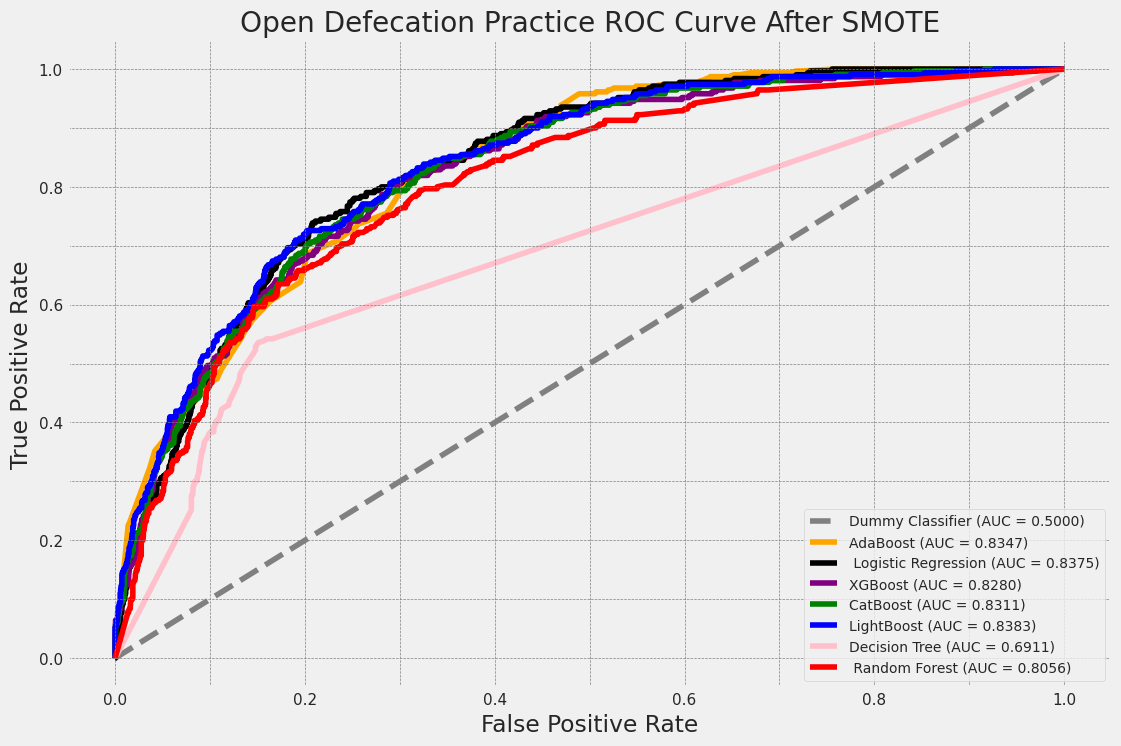

In [ ]:
# Combine metrics into a DataFrame for display
import matplotlib.pyplot as plt
######----------For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(15,5)})
plt.style.use('fivethirtyeight')

metrics_df = pd.DataFrame({
    "Model": ["Dummy Classifiert","Random Forest", "Decision Tree",  "XGBoost", "Logistic Regression",  "Light Boost",  "AdaBoost", "catBoost"],
    "Accuracy": [dummy_metrics[0], rf_metrics[0],  dt_metrics[0],  xgb_metrics[0], lr_metrics[0],  lgb_metrics[0],  ada_metrics[0], cat_metrics[0]],
    "AUC": [dummy_metrics[1], rf_metrics[1],  dt_metrics[1],  xgb_metrics[1], lr_metrics[1],  lgb_metrics[1],  ada_metrics[1],  cat_metrics[1]],
    "Precision": [dummy_metrics[2], rf_metrics[2],  dt_metrics[2], xgb_metrics[2], lr_metrics[2],  lgb_metrics[2],  ada_metrics[2], cat_metrics[2]],
    "Recall": [dummy_metrics[3], rf_metrics[3],  dt_metrics[3],  xgb_metrics[3], lr_metrics[3], lgb_metrics[3],  ada_metrics[3], cat_metrics[3]],
    "F1-score": [dummy_metrics[4], rf_metrics[4],  dt_metrics[4],  xgb_metrics[4], lr_metrics[4],  lgb_metrics[4],  ada_metrics[4], cat_metrics[4]],

})

# Display the metrics
print(metrics_df)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Plot all ROC curves
plt.figure(figsize=(12, 8))
plt.plot(dummy_fpr, dummy_tpr, color="gray", linestyle="--", label=f"Dummy Classifier (AUC = {dummy_metrics[1]:.4f})")
plt.plot(ada_fpr, ada_tpr, color="orange", label=f"AdaBoost (AUC = {ada_metrics[1]:.4f})")



plt.plot(lr_fpr, lr_tpr, color="black", label=f" Logistic Regression (AUC = {lr_metrics[1]:.4f})")

plt.plot(xgb_fpr, xgb_tpr, color="purple", label=f"XGBoost (AUC = {xgb_metrics[1]:.4f})")
plt.plot(cat_fpr, cat_tpr, color="green", label=f"CatBoost (AUC = {cat_metrics[1]:.4f})")
plt.plot(lgb_fpr, lgb_tpr, color="blue", label=f"LightBoost (AUC = {lgb_metrics[1]:.4f})")
plt.plot(dt_fpr, dt_tpr, color="pink", label=f"Decision Tree (AUC = {dt_metrics[1]:.4f})")
plt.plot(rf_fpr, rf_tpr, color="red", label=f" Random Forest (AUC = {rf_metrics[1]:.4f})")
# Add vertical lines on the x-axis (False Positive Rate)
for x in np.arange(0.0, 1.1, 0.1):  # Adjust the range and step size as needed
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)

# Add horizontal lines on the y-axis (True Positive Rate)
for y in np.arange(0.0, 1.1, 0.1):  # Adjust the range and step size as needed
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.5)

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Open Defecation Practice ROC Curve After SMOTE")
plt.legend(loc="lower right", fontsize=10)
plt.grid()
plt.show()


In [ ]:
!pip install optuna scikit-learn pandas imbalanced-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score
)







In [ ]:
# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob[:, 1])
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }





In [ ]:
# Baseline evaluation

y_pred = lgb_clf.predict(X_test)
y_prob = lgb_clf.predict_proba(X_test)
metrics_before = evaluate_model(y_test, y_pred, y_prob)


In [ ]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Balanced training set: X_train_bal, y_train_bal

def objective(trial):
    # Define search space with min/max ranges
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        # Add n_estimators to the search space
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),  # min=100, max=2000
    }

    # Model
    model = lgb.LGBMClassifier(**params)

    # Stratified CV
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in cv.split(X_train_bal, y_train_bal):
        X_train_cv, X_val_cv = X_train_bal.iloc[train_idx], X_train_bal.iloc[val_idx]
        y_train_cv, y_val_cv = y_train_bal.iloc[train_idx], y_train_bal.iloc[val_idx]

        # Skip folds with only one class
        if len(np.unique(y_train_cv)) < 2 or len(np.unique(y_val_cv)) < 2:
            continue

        model.fit(X_train_cv, y_train_cv)
        val_probs = model.predict_proba(X_val_cv)[:, 1]
        aucs.append(roc_auc_score(y_val_cv, val_probs))

    # If no valid folds, return a very low score
    if len(aucs) == 0:
        return 0.0

    return np.mean(aucs)



In [ ]:



study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best AUC:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-04-27 11:28:22,386] A new study created in memory with name: no-name-f7271ccd-2085-4e52-8991-87cdbdc6b52c
[I 2026-04-27 11:29:53,258] Trial 0 finished with value: 0.9439804270586839 and parameters: {'learning_rate': 0.0035909783890950417, 'num_leaves': 209, 'max_depth': 15, 'min_child_samples': 68, 'subsample': 0.7257618518126281, 'colsample_bytree': 0.9344151488402954, 'reg_alpha': 8.738717113066158e-05, 'reg_lambda': 0.00013044233944415522, 'n_estimators': 1507}. Best is trial 0 with value: 0.9439804270586839.
[I 2026-04-27 11:30:18,739] Trial 1 finished with value: 0.9507115226241133 and parameters: {'learning_rate': 0.03461847785932669, 'num_leaves': 204, 'max_depth': 13, 'min_child_samples': 73, 'subsample': 0.9295090590402255, 'colsample_bytree': 0.598010199225537, 'reg_alpha': 0.00920070469903845, 'reg_lambda': 4.4459017871336564e-07, 'n_estimators': 506}. Best is trial 1 with value: 0.9507115226241133.
[I 2026-04-27 11:31:24,726] Trial 2 finished with value: 0.943886588

Best AUC: 0.9596810456695121
Best parameters: {'learning_rate': 0.03788573841293071, 'num_leaves': 127, 'max_depth': 14, 'min_child_samples': 11, 'subsample': 0.7160352567503501, 'colsample_bytree': 0.5226042812270162, 'reg_alpha': 9.335167576217973e-05, 'reg_lambda': 4.875206628178505e-07, 'n_estimators': 939}


Best Parameters: {'learning_rate': 0.03788573841293071, 'num_leaves': 127, 'max_depth': 14, 'min_child_samples': 11, 'subsample': 0.7160352567503501, 'colsample_bytree': 0.5226042812270162, 'reg_alpha': 9.335167576217973e-05, 'reg_lambda': 4.875206628178505e-07, 'n_estimators': 939}


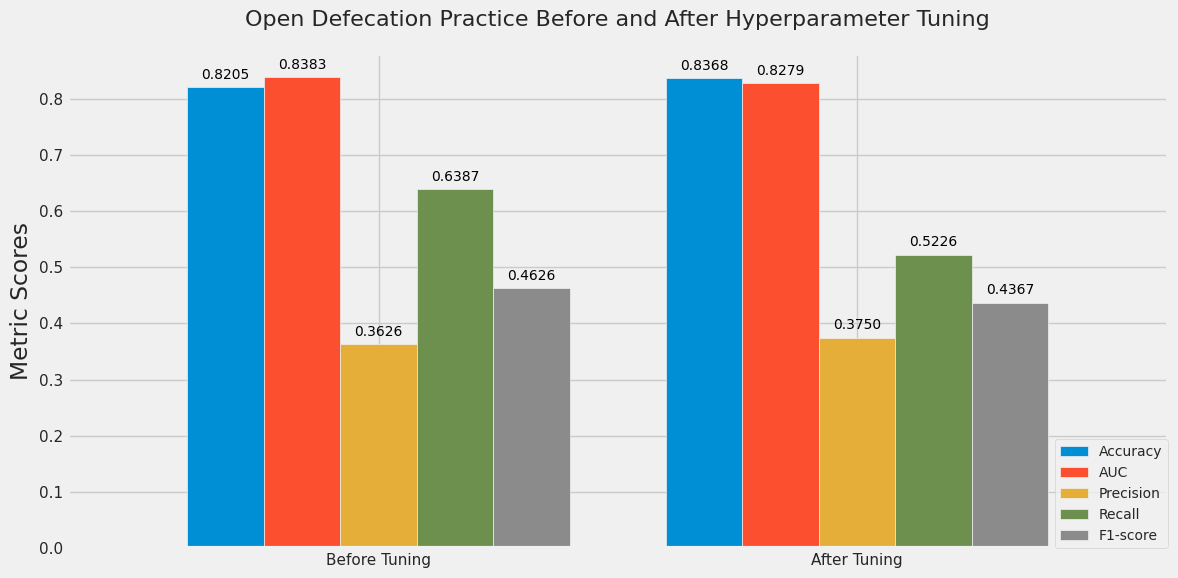

               Accuracy       AUC  Precision    Recall  F1-score
Before Tuning  0.820453  0.838268   0.362637  0.638710  0.462617
After Tuning   0.836846  0.827866   0.375000  0.522581  0.436658


In [ ]:
# Train the final model with the best parameters
best_params = study.best_params

# Print Best Parameters
print("Best Parameters:", study.best_params)
lgb_optimized = LGBMClassifier(random_state=42, **best_params)
lgb_optimized.fit(X_train_bal, y_train_bal)
y_pred_optimized = lgb_optimized.predict(X_test)
y_prob_optimized = lgb_optimized.predict_proba(X_test)
metrics_after = evaluate_model(y_test, y_pred_optimized, y_prob_optimized)
# Compare metrics
metrics_df = pd.DataFrame([metrics_before, metrics_after], index=["Before Tuning", "After Tuning"])

# Plot the histogram
ax = metrics_df.plot(kind="bar", figsize=(12, 6), width=0.8)




# Add values at the top of each bar
for bar_group in ax.containers:  # Iterate through groups of bars
    for bar in bar_group:
        height = bar.get_height()  # Get bar height
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Center text horizontally
            height + 0.01,  # Position text slightly above the bar
            f'{height:.4f}',  # Format values to 2 decimal places
            ha='center', va='bottom', fontsize=10, color='black'  # Align and style text
        )

# Adjust title, spacing, and layout
plt.title("Open Defecation Practice Before and After Hyperparameter Tuning", fontsize=16, pad=20)  # Increase title spacing
plt.ylabel("Metric Scores")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.legend(loc="lower right",  borderaxespad=0., fontsize=10)

plt.tight_layout()  # Automatically adjust layout to prevent overlap

plt.show()



print(metrics_df)


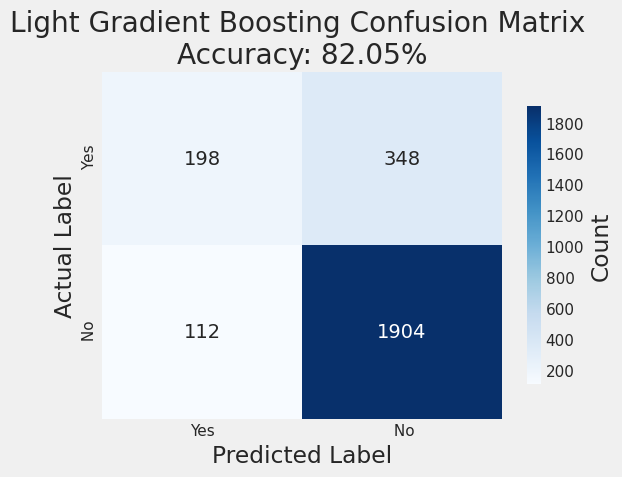

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Predict test labels using lGBoost
lgb_preds = lgb_clf.predict(X_test)

# Generate confusion matrix
lgb_cm = confusion_matrix(y_test, lgb_preds)

# Extract values
TP = lgb_cm[1,1]
FP = lgb_cm[0,1]
FN = lgb_cm[1,0]
TN = lgb_cm[0,0]

# Compute accuracy and convert to percentage
lgb_accuracy = accuracy_score(y_test, lgb_preds)
lgb_accuracy_percent = lgb_accuracy * 100

# Create matrix with values
matrix_values = np.array([[TP, FP],
                          [FN, TN]])

# Create matrix with labels
matrix_labels = np.array([[f"{TP}", f"{FP}"],
                          [f"{FN}", f"{TN}"]])

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(matrix_values, annot=matrix_labels, fmt='', cmap='Blues',
            xticklabels=["Yes", " No"],
            yticklabels=[" Yes", " No"],
            cbar=True, cbar_kws={"label": "Count", "shrink": 0.8})

plt.title(f"Light Gradient Boosting Confusion Matrix \nAccuracy: {lgb_accuracy_percent:.2f}%")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [ ]:
!pip install imbalanced-learn shap

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt



In [ ]:
explainer = shap.TreeExplainer(lgb_clf)
shap_values = explainer.shap_values(X_test)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


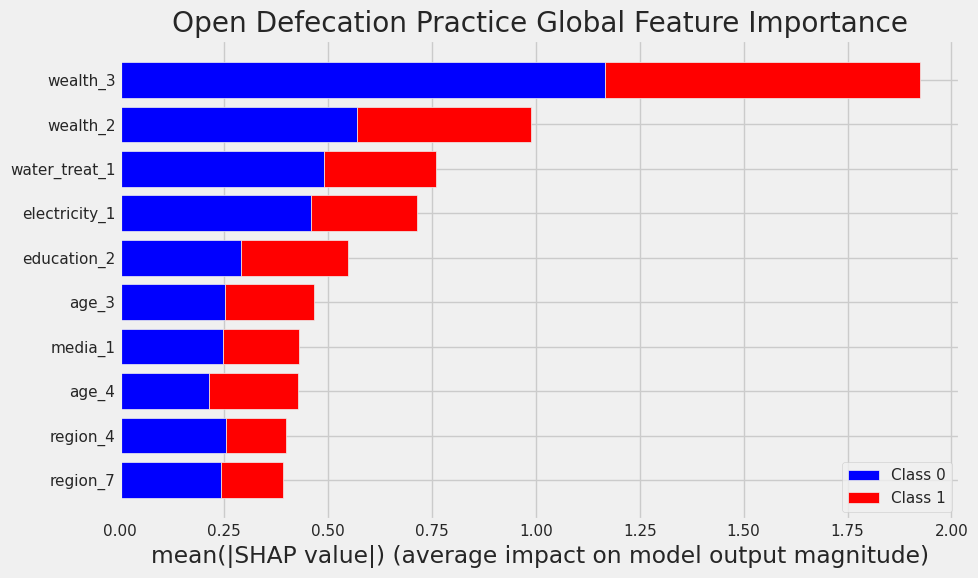

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. SHAP explainer (model-agnostic)
# --------------------------------------------------


# Convert to numeric array
shap_vals = shap_values  # shape: (n_samples_test, n_features)

# --------------------------------------------------
# 2. Predicted probabilities → class masks
# --------------------------------------------------
proba = cat_model.predict_proba(X_test)[:, 1]
class0_mask = proba < 0.5
class1_mask = proba >= 0.5

# --------------------------------------------------
# 3. Class-wise mean(|SHAP|) per feature
# --------------------------------------------------
n_features = shap_vals.shape[1]

mean_shap_class0 = (
    np.mean(np.abs(shap_vals[class0_mask]), axis=0)
    if np.any(class0_mask)
    else np.zeros(n_features)
)

mean_shap_class1 = (
    np.mean(np.abs(shap_vals[class1_mask]), axis=0)
    if np.any(class1_mask)
    else np.zeros(n_features)
)

features = X_test.columns.to_numpy()

# --------------------------------------------------
# 4. Sort top features by total importance
# --------------------------------------------------
total_importance = mean_shap_class0 + mean_shap_class1
top_n = 10
top_idx = np.argsort(total_importance)[-top_n:][::-1]

features_top = features[top_idx]
class0_top = mean_shap_class0[top_idx]
class1_top = mean_shap_class1[top_idx]

# --------------------------------------------------
# 5. Stacked horizontal bar plot
# --------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(features_top, class0_top, color='blue', label='Class 0')
plt.barh(features_top, class1_top, left=class0_top, color='red', label='Class 1')
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.gca().invert_yaxis()
plt.legend()
plt.title("Open Defecation Practice Global Feature Importance")
plt.tight_layout()
plt.show()





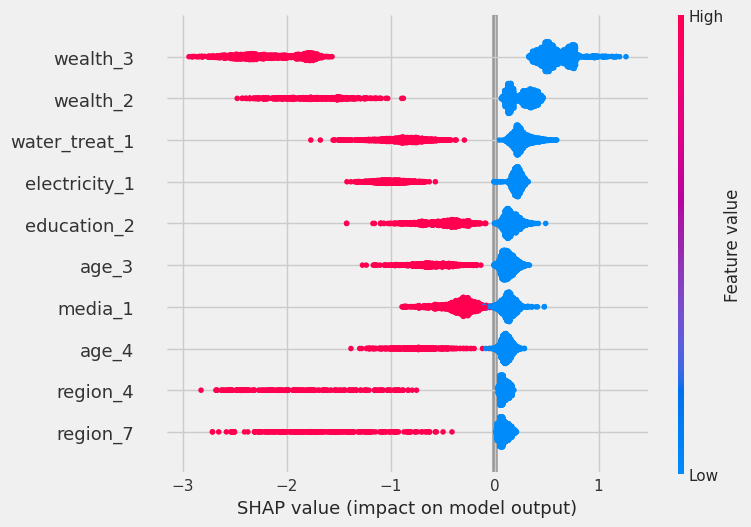

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. SHAP values already computed
# --------------------------------------------------
shap_vals = shap_values  # shape: (n_samples_test, n_features)

# --------------------------------------------------
# 2. Predicted probabilities → class masks
# --------------------------------------------------
proba = cat_model.predict_proba(X_test)[:, 1]
class0_mask = proba < 0.5
class1_mask = proba >= 0.5

# Assign a color to each sample based on predicted class
colors = np.array(['blue' if p < 0.5 else 'red' for p in proba])

# --------------------------------------------------
# 3. Compute mean(|SHAP|) per feature for each class
# --------------------------------------------------
n_features = shap_vals.shape[1]

mean_shap_class0 = (
    np.mean(np.abs(shap_vals[class0_mask]), axis=0)
    if np.any(class0_mask)
    else np.zeros(n_features)
)
mean_shap_class1 = (
    np.mean(np.abs(shap_vals[class1_mask]), axis=0)
    if np.any(class1_mask)
    else np.zeros(n_features)
)

# Total importance across both classes
total_importance = mean_shap_class0 + mean_shap_class1

# --------------------------------------------------
# 4. Select top 10 features by total importance
# --------------------------------------------------
top_n = 10
top_idx = np.argsort(total_importance)[-top_n:][::-1]

X_top = X_test.iloc[:, top_idx]   # top features
shap_top = shap_vals[:, top_idx]
features_top = X_test.columns.to_numpy()[top_idx]

# --------------------------------------------------
# 5. SHAP summary plot (beeswarm) with fixed order
# --------------------------------------------------
shap.summary_plot(
    shap_top,                # SHAP values for top features
    X_top,                   # corresponding feature values
    feature_names=features_top,
    plot_type="dot",         # beeswarm style
    color=colors,            # color by predicted class
    max_display=top_n,
    sort=False               # keep the order we pass in
)


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving df_open_dee.csv to df_open_dee.csv


In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('df_open_dee.csv')

In [ ]:
data

,internet_0,internet_1,water_access_0,water_access_1,region_1,region_2,region_3,region_4,region_5,region_6,...,water_treat_1,under5_0,under5_1,under5_2,under5_3,wealth_1,wealth_2,wealth_3,open_defecation_0,open
0,1,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1,0
1,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1,0
2,1,0,0,1,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,1,0
3,1,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
4,1,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12803,1,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
12804,1,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
12805,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
12806,1,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Import necessary library
import pandas as pd

# Load dataset (replace 'dataset.csv' with  actual file)

# Define mapping for column replacement
region_columns = {

    'region_1': 'Central',
    'region_2': 'Copperbelt',
    'region_3': 'Eastern',
    'region_4': 'Luapula',
    'region_5': 'Lusaka',
    'region_6': 'Muchinga',
    'region_7': 'Northern',
    'region_8': 'North western',
    'region_9': 'Southern',
    'region_10': 'Western',
}

# Rename columns
data.rename(columns=region_columns, inplace=True)

# Display updated DataFrame
print(data.head())

   internet_0  internet_1  water_access_0  water_access_1  Central  \
0           1           0               1               0        0   
1           0           1               0               1        0   
2           1           0               0               1        0   
3           1           0               1               0        0   
4           1           0               1               0        0   

   Copperbelt  Eastern  Luapula  Lusaka  Muchinga  ...  water_treat_1  \
0           0        0        0       0         0  ...              0   
1           0        0        0       0         0  ...              0   
2           0        0        0       0         0  ...              1   
3           0        0        0       0         0  ...              0   
4           0        0        0       0         0  ...              0   

   under5_0  under5_1  under5_2  under5_3  wealth_1  wealth_2  wealth_3  \
0         1         0         0         0         0         0    

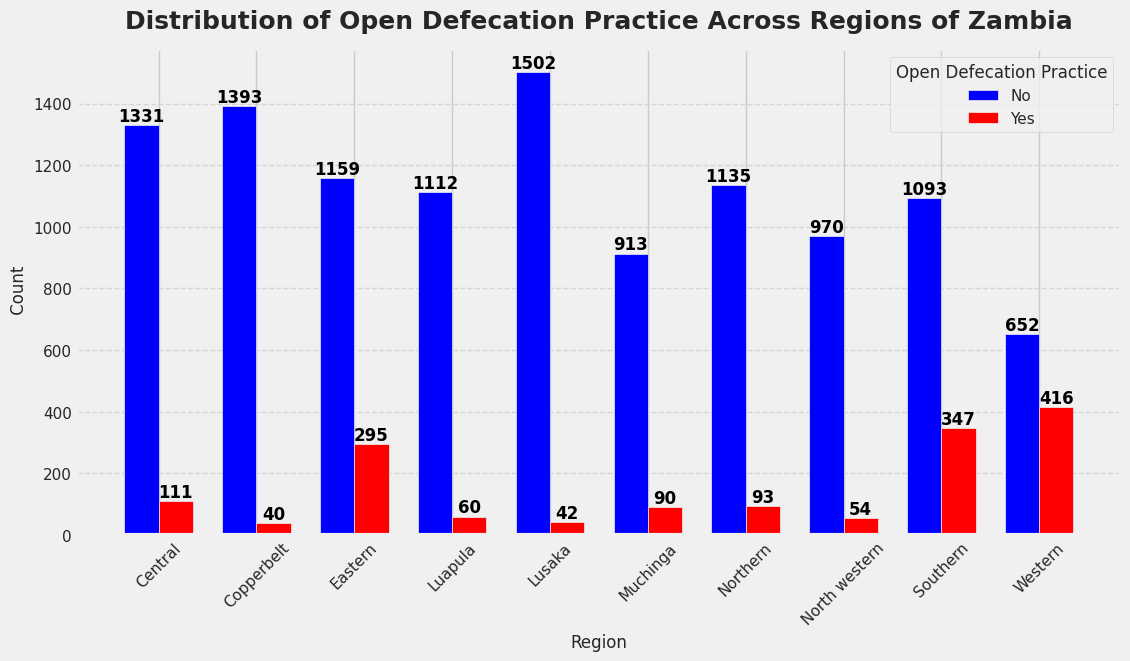

In [ ]:



# Load dataset (replace 'dataset.csv' with  actual file)

# Define country columns (after renaming them)
region_columns = ['Central', 'Copperbelt', 'Eastern', 'Luapula', 'Lusaka',
                   'Muchinga', 'Northern', 'North western', 'Southern', 'Western',
                   ]

# Initialize lists for structured data
region_list = []
no_list = []
yes_list = []

# Loop through each country column to count values (0 and 1)
for region in region_columns:
    region_list.append(region)
    no_list.append((data[data[region] == 1]['open'] == 0).sum())  # Count 'No' cases
    yes_list.append((data[data[region] == 1]['open'] == 1).sum())  # Count 'Yes' cases



# Create a DataFrame for visualization
kfp_df = pd.DataFrame({'region': region_list, 'No': no_list, 'Yes': yes_list})

# Set bar width and position for separate bars
x = np.arange(len(region_list))
bar_width = 0.35

# Create bar chart
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, kfp_df['No'], color='blue', width=bar_width, label='No')
bars2 = plt.bar(x + bar_width/2, kfp_df['Yes'], color='red', width=bar_width, label='Yes')

# Add values on top of bars
for bar, bar2 in zip(bars1, bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.0f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    plt.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height(),
             f'{bar2.get_height():.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Add title and labels
plt.title('Distribution of Open Defecation Practice Across Regions of Zambia', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel(' Count', fontsize=12)
plt.xticks(x, region_list, rotation=45, fontsize=11)
plt.legend(title="Open Defecation Practice", loc='upper right')

# Show graph
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
